In [1]:
# Group Members: Artificial Intelligence.....
# 1. 105241- William Kagoiyo Wabuiya
# 2. 170459- Ryan Maxine.
# 3. 169258- Samuel K. Ptolomy.
# 4. 133865- Franklyne Olunga Mayende.
# 5. 088251 - Claire Naibo

# "Dataset: Stars Classification"
#------------------------------------------------------
#Eager Classifier: SVM- Support Vector Machine"
#------------------------------------------------------

In [2]:
# QN 1: Importing the necessary libraries and loading the dataset
# We start by importing every library we will need throughout
# this notebook. This includes libraries for data manipulation, visualization, and machine learning.

import pandas as pd          # for loading and manipulating our data table
import numpy as np           # for numerical operations
import matplotlib.pyplot as plt  # for drawing charts and graphs
import seaborn as sns        # for prettier, more informative charts

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC                          # Support Vector Classifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')   # keeps our output clean during presentation

# ---------------------------------------------------------------
# Loading the dataset.
# ---------------------------------------------------------------
df = pd.read_csv('Stars.csv')

print("Dataset loaded successfully!")
print(f"Shape of dataset: {df.shape}")   # rows x columns
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows of the raw data:")
df.head()


Dataset loaded successfully!
Shape of dataset: (240, 8)

Column names:
['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']

First 5 rows of the raw data:


,Temperature (K),Luminosity (L/Lo),Radius (R/Ro),Absolute magnitude (Mv),Star type,Star category,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,0,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,0,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,0,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,0,Brown Dwarf,Red,M


STEP 1A: Basic Data Overview
<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (K)          240 non-null    int64  
 1   Luminosity (L/Lo)        240 non-null    float64
 2   Radius (R/Ro)            240 non-null    float64
 3   Absolute magnitude (Mv)  240 non-null    float64
 4   Star type                240 non-null    int64  
 5   Star category            240 non-null    str    
 6   Star color               240 non-null    str    
 7   Spectral Class           240 non-null    str    
dtypes: float64(3), int64(2), str(3)
memory usage: 15.1 KB
None

Descriptive Statistics (numerical columns):
       Temperature (K)  Luminosity (L/Lo)  Radius (R/Ro)  \
count       240.000000         240.000000     240.000000   
mean      10497.462500      107188.361635     237.157781   
std        9552.425037      179432.244940     517

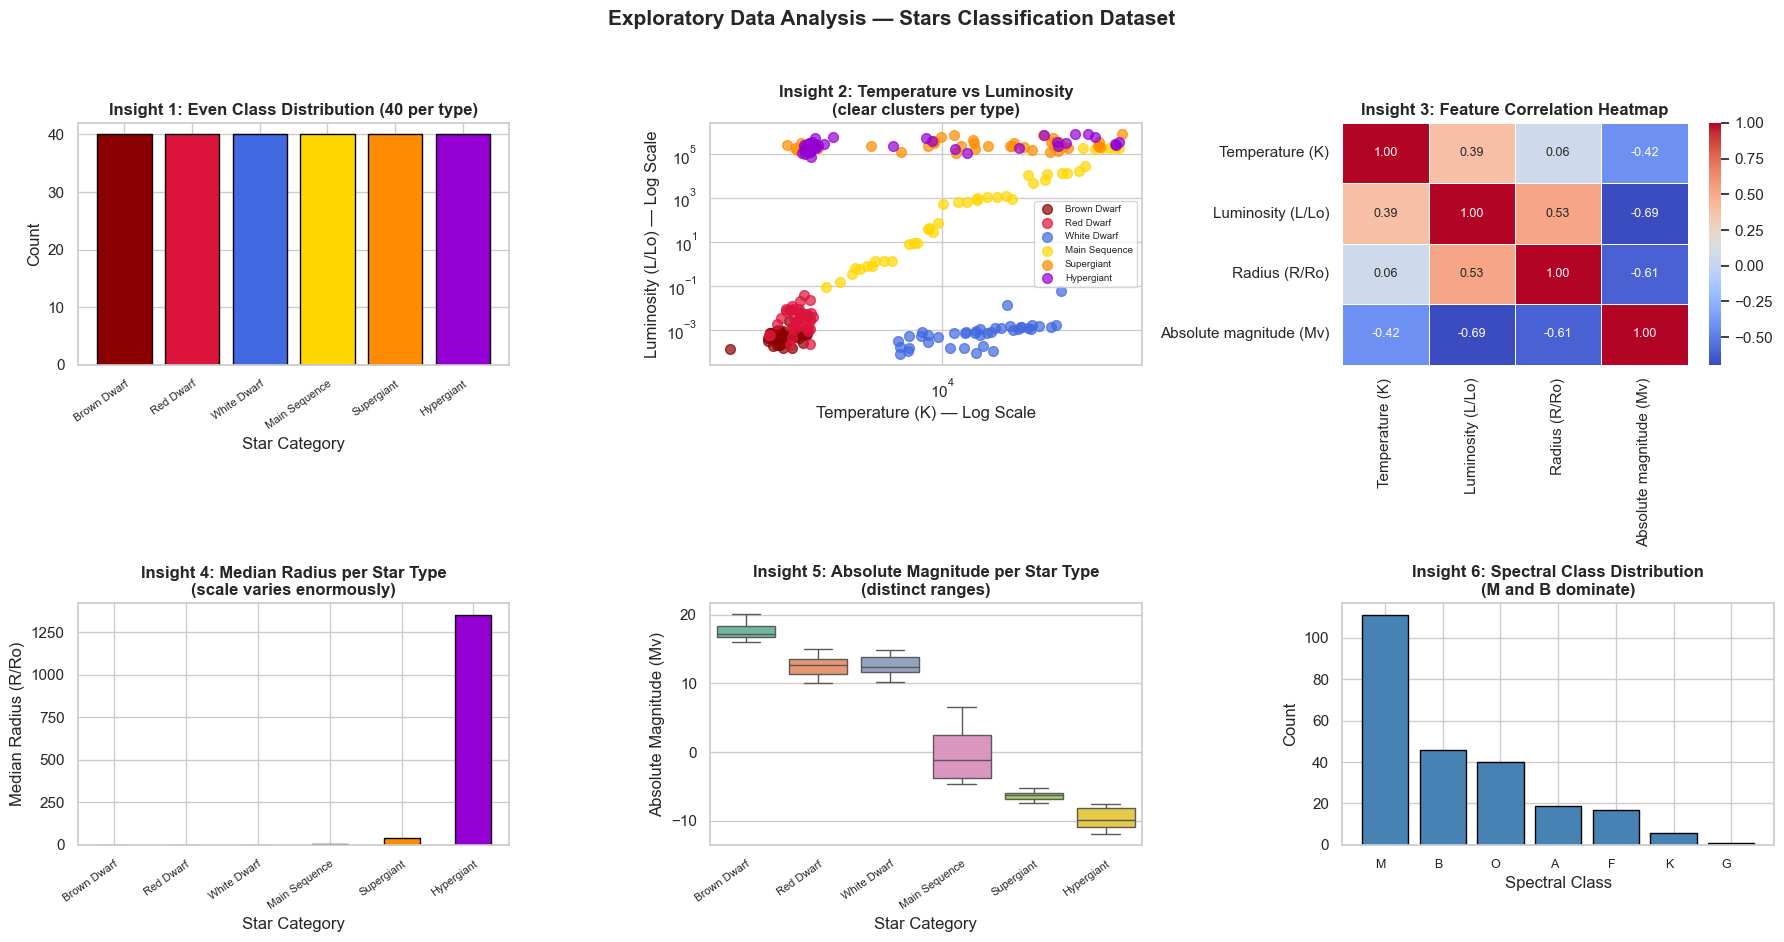


SUMMARY OF EDA INSIGHTS

Insight 1 — Perfectly balanced dataset:
  Each of the 6 star types has exactly 40 records. This is ideal
  for classification because the model is not biased toward
  any single class.

Insight 2 — Temperature & Luminosity form distinct clusters:
  On log scales, these two features show clear separation among
  star categories, making them highly informative predictors.

Insight 3 — Moderate negative correlation (not extreme):
  Temperature and Absolute Magnitude have a moderate negative
  correlation (about -0.42). Hotter stars generally have lower
  (brighter) magnitude values.

Insight 4 — Radius varies enormously across classes:
  Hypergiants have a much larger median radius than dwarf classes.
  This confirms a very wide scale range across star types.

Insight 5 — Absolute Magnitude separates classes well:
  The box plot shows mostly distinct magnitude ranges by class,
  with limited overlap, so this feature has strong class-separation power.

Insight 6 —

In [10]:
# =============================================================
# QUESTION 2: Data Cleaning + Exploratory Data Analysis (EDA) - After appropriately cleaning the data,
# carry out Exploratory Data Analysis processes to retrieve at least 4 insights/observations from the dataset.
# =============================================================
# Before we build any model, we need to understand our data
# and make sure it is clean. "Garbage in, garbage out" is a
# real risk in machine learning — a dirty dataset will produce
# an unreliable model no matter how sophisticated the algorithm.

# ---------------------------------------------------------------
# STEP 1: Basic overview — what does the data look like?
# ---------------------------------------------------------------
print("=" * 60)
print("STEP 1A: Basic Data Overview")
print("=" * 60)
print(df.info())          # data types and non-null counts per column
print("\nDescriptive Statistics (numerical columns):")
print(df.describe())       # min, max, mean, std for each numeric column

# ---------------------------------------------------------------
# STEP 1B: Additional Statistics for deeper insight
# We explicitly calculate mean, mode, median, and standard deviation
# so the statistical interpretation is clearer than describe() alone.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 1B: Additional Descriptive Statistics (Mean, Mode, Median, Std)")
print("=" * 60)

# Select numeric features only for statistical analysis.
numeric_cols = ['Temperature (K)', 'Luminosity (L/Lo)',
                'Radius (R/Ro)', 'Absolute magnitude (Mv)']

# Use first mode per column to keep output compact and presentation-friendly.
mode_values = df[numeric_cols].mode().iloc[0]

# Build one clean table with the requested statistics.
stats_table = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Mode': mode_values,
    'Median': df[numeric_cols].median(),
    'Std Dev': df[numeric_cols].std()
}).round(3)

print("\nOverall statistics for numeric features:")
print(stats_table)

# Class-level statistics help explain how star types differ in central tendency and spread.
# We derive readable labels here because the main Star category column is created later in STEP 5.
star_type_labels = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
class_stats = (
    df.assign(**{'Star category': df['Star type'].map(star_type_labels)})
      .groupby('Star category')[numeric_cols]
      .agg(['mean', 'median', 'std'])
      .round(3)
)
print("\nClass-level statistics by Star category (mean, median, std):")
print(class_stats)

# ---------------------------------------------------------------
# STEP 2: Check for missing values
# A missing value means a cell in our table has no data.
# If we leave missing values in, they will cause errors when
# we try to train models later.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 2: Missing Values Check")
print("=" * 60)
print(df.isnull().sum())

# ---------------------------------------------------------------
# STEP 3: Check for duplicate rows
# A duplicate row is a row that is an exact copy of another.
# Keeping duplicates can bias our model by making it learn
# the same example more than once.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 3: Duplicate Rows Check")
print("=" * 60)
print(f"Number of duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# ---------------------------------------------------------------
# STEP 4: Check class balance in the target column
# Our target is 'Star type' — a number from 0 to 5.
# We check if all 6 classes have roughly equal representation.
# Severe imbalance can make a classifier biased toward the
# majority class.
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("STEP 4: Target Class Distribution (Star type)")
print("=" * 60)
print(df['Star type'].value_counts())

# ---------------------------------------------------------------
# STEP 5: Map the numeric Star type to its readable label
# so our plots are self-explanatory to the lecturer.
# ---------------------------------------------------------------
star_labels = {
    0: 'Brown Dwarf',
    1: 'Red Dwarf',
    2: 'White Dwarf',
    3: 'Main Sequence',
    4: 'Supergiant',
    5: 'Hypergiant'
}
df['Star category'] = df['Star type'].map(star_labels)

print("\nCleaned dataset — first 5 rows:")
df.head()

# =============================================================
# QUESTION 2 (continued): Exploratory Data Analysis — Insights
# We now create visualizations to draw at least 4 meaningful
# insights from the Stars dataset.
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Exploratory Data Analysis — Stars Classification Dataset',
    fontsize=15, fontweight='bold'
)

# Keep categorical tick labels readable across crowded subplots.
def format_categorical_xticks(ax, rotation=35, fontsize=8):
    ax.tick_params(axis='x', pad=4, labelsize=fontsize)
    for label in ax.get_xticklabels():
        label.set_rotation(rotation)
        label.set_ha('right')
        label.set_rotation_mode('anchor')

# ---------------------------------------------------------------
# INSIGHT 1: Class Distribution
# We want to confirm that each star type has an equal number
# of records (40 each). A balanced dataset is important because
# it means our classifier will be trained on fair representation
# of all classes — no single class will dominate.
# ---------------------------------------------------------------
category_counts = df['Star category'].value_counts()
axes[0, 0].bar(category_counts.index, category_counts.values,
               color=['#8B0000','#DC143C','#4169E1','#FFD700','#FF8C00','#9400D3'],
               edgecolor='black')
axes[0, 0].set_title('Insight 1: Even Class Distribution (40 per type)',
                     fontweight='bold')
axes[0, 0].set_xlabel('Star Category')
axes[0, 0].set_ylabel('Count')
format_categorical_xticks(axes[0, 0], rotation=35)

# ---------------------------------------------------------------
# INSIGHT 2: Temperature vs Luminosity (Log Scale)
# Temperature and Luminosity vary by many orders of magnitude
# across star types, so we use a log scale.
# This chart (similar to the Hertzsprung-Russell diagram in
# astronomy) shows clear clusters for each star type, which
# tells us these two features will be very powerful for
# classification.
# ---------------------------------------------------------------
colors = {
    'Brown Dwarf': '#8B0000', 'Red Dwarf': '#DC143C',
    'White Dwarf': '#4169E1', 'Main Sequence': '#FFD700',
    'Supergiant': '#FF8C00', 'Hypergiant': '#9400D3'
}
for category, color in colors.items():
    subset = df[df['Star category'] == category]
    axes[0, 1].scatter(
        subset['Temperature (K)'],
        subset['Luminosity (L/Lo)'],
        label=category, color=color, alpha=0.7, s=50
    )
axes[0, 1].set_yscale('log')    # log scale because values span many orders of magnitude
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Insight 2: Temperature vs Luminosity\n(clear clusters per type)',
                     fontweight='bold')
axes[0, 1].set_xlabel('Temperature (K) — Log Scale')
axes[0, 1].set_ylabel('Luminosity (L/Lo) — Log Scale')
axes[0, 1].legend(fontsize=7)

# ---------------------------------------------------------------
# INSIGHT 3: Correlation Heatmap of Numeric Features
# A correlation heatmap shows how strongly each pair of
# numeric features moves together. Values close to +1 or -1
# indicate strong relationships. Here, Temperature and
# Absolute Magnitude show a moderate negative correlation
# (about -0.42): hotter stars tend to have lower (brighter)
# magnitude values.
# ---------------------------------------------------------------
numeric_df = df[['Temperature (K)', 'Luminosity (L/Lo)',
                 'Radius (R/Ro)', 'Absolute magnitude (Mv)']].copy()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0, 2], linewidths=0.5, annot_kws={'size': 9})
axes[0, 2].set_title('Insight 3: Feature Correlation Heatmap',
                     fontweight='bold')

# ---------------------------------------------------------------
# INSIGHT 4: Radius Distribution by Star Type
# Hypergiants and Supergiants have massively larger radii than
# other star types. Brown Dwarfs and White Dwarfs have very
# small radii. This huge range means scaling our features
# before training is essential — otherwise larger-valued
# features will dominate distance calculations.
# ---------------------------------------------------------------
df.groupby('Star category')['Radius (R/Ro)'].median().reindex(
    ['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
     'Main Sequence', 'Supergiant', 'Hypergiant']
).plot(kind='bar', ax=axes[1, 0],
       color=['#8B0000','#DC143C','#4169E1','#FFD700','#FF8C00','#9400D3'],
       edgecolor='black')
axes[1, 0].set_title('Insight 4: Median Radius per Star Type\n(scale varies enormously)',
                     fontweight='bold')
axes[1, 0].set_ylabel('Median Radius (R/Ro)')
axes[1, 0].set_xlabel('Star Category')
format_categorical_xticks(axes[1, 0], rotation=35)

# ---------------------------------------------------------------
# INSIGHT 5: Absolute Magnitude by Star Type (Box Plot)
# Absolute magnitude measures intrinsic brightness.
# The box plot shows that each star type occupies a distinct
# range of brightness, with very little overlap — meaning
# Absolute Magnitude alone would be quite a good classifier.
# This reinforces it as one of our chosen features.
# ---------------------------------------------------------------
category_order = ['Brown Dwarf', 'Red Dwarf', 'White Dwarf',
                  'Main Sequence', 'Supergiant', 'Hypergiant']
df_plot = df.copy()
df_plot['Star category'] = pd.Categorical(df_plot['Star category'],
                                          categories=category_order, ordered=True)
df_plot.sort_values('Star category', inplace=True)
sns.boxplot(data=df_plot, x='Star category', y='Absolute magnitude (Mv)',
            palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Insight 5: Absolute Magnitude per Star Type\n(distinct ranges)',
                     fontweight='bold')
axes[1, 1].set_xlabel('Star Category')
axes[1, 1].set_ylabel('Absolute Magnitude (Mv)')
format_categorical_xticks(axes[1, 1], rotation=35)

# ---------------------------------------------------------------
# INSIGHT 6: Spectral Class Distribution
# Most stars in the dataset are classified under spectral class
# M (cool, red) or B (hot, blue). This confirms the diversity
# of star types in the dataset and also shows ambiguity:
# both Brown Dwarfs and Red Dwarfs can appear under class M,
# so spectral class alone is not sufficient for classification.
# ---------------------------------------------------------------
spectral_counts = df['Spectral Class'].value_counts()
axes[1, 2].bar(spectral_counts.index, spectral_counts.values,
               color='steelblue', edgecolor='black')
axes[1, 2].set_title('Insight 6: Spectral Class Distribution\n(M and B dominate)',
                     fontweight='bold')
axes[1, 2].set_xlabel('Spectral Class')
axes[1, 2].set_ylabel('Count')
format_categorical_xticks(axes[1, 2], rotation=0, fontsize=9)

plt.tight_layout(rect=(0, 0.04, 1, 0.96))
plt.show()

# ---------------------------------------------------------------
# Summary of insights for the lecturer
# ---------------------------------------------------------------
print("""
======================================================================
SUMMARY OF EDA INSIGHTS
======================================================================

Insight 1 — Perfectly balanced dataset:
  Each of the 6 star types has exactly 40 records. This is ideal
  for classification because the model is not biased toward
  any single class.

Insight 2 — Temperature & Luminosity form distinct clusters:
  On log scales, these two features show clear separation among
  star categories, making them highly informative predictors.

Insight 3 — Moderate negative correlation (not extreme):
  Temperature and Absolute Magnitude have a moderate negative
  correlation (about -0.42). Hotter stars generally have lower
  (brighter) magnitude values.

Insight 4 — Radius varies enormously across classes:
  Hypergiants have a much larger median radius than dwarf classes.
  This confirms a very wide scale range across star types.

Insight 5 — Absolute Magnitude separates classes well:
  The box plot shows mostly distinct magnitude ranges by class,
  with limited overlap, so this feature has strong class-separation power.

Insight 6 — Spectral class alone is ambiguous:
  Brown Dwarfs and Red Dwarfs both appear in spectral class M,
  so spectral class alone cannot reliably classify stars.

Insight 7 — Mean vs Median indicates right-skewness:
  In Luminosity and Radius, the mean is far above the median,
  indicating right-skewed distributions caused by very large stars.

Insight 8 — Large standard deviations confirm high variability:
  Temperature and Luminosity have high standard deviations,
  reinforcing the need for feature scaling before modeling.
======================================================================
""")

In [ ]:
#QN 3: Create a model based on the k-Nearest Neighbors algorithm for classification based on at least 2 suitable features for one target variable. Verify the optimal k for classification.


In [ ]:
#QN 4: Create another eager learning classifier as assigned based on at least 2 suitable features for one target variable.


In [ ]:
#QN 5: For the eager learner created in Q4, create another model with tuned hyperparameters that enhance the accuracy of classification.


In [ ]:
#QN 6: Evaluate the performances of the three models created in Q3, Q4 and Q5. Use the confusion matrix metric to evaluate the performances.
